In [ ]:
# Project 2: Energy Efficiency Prediction for Buildings

#This notebook builds regression models to predict Heating Load and Cooling Load using building characteristics.

#The work follows the required project tasks only:

#- Data preprocessing
#- Feature scaling
#- Linear Regression
#- SVR with linear kernel
#- SVR with RBF kernel
#- Neural Network
#- Hyperparameter tuning
#- Evaluation using RMSE, MAE, and R²
#- Predicted vs actual plot for the best model

In [25]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [26]:
# 2. Load Dataset
df = pd.read_csv("energy_efficiency_data.csv")
df.head()


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


In [27]:
# 3. Inspect Dataset
print("Dataset shape:")
print(df.shape)

print("\nColumn names:")
print(df.columns)

print("\nDataset information:")
df.info()


Dataset shape:
(768, 10)

Column names:
Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution', 'Heating_Load', 'Cooling_Load'],
      dtype='object')

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Relative_Compactness       768 non-null    float64
 1   Surface_Area               768 non-null    float64
 2   Wall_Area                  768 non-null    float64
 3   Roof_Area                  768 non-null    float64
 4   Overall_Height             768 non-null    float64
 5   Orientation                768 non-null    int64  
 6   Glazing_Area               768 non-null    float64
 7   Glazing_Area_Distribution  768 non-null    int64  
 8   Heating_Load               768 non-null    float

In [28]:
df.describe()


,Relative_Compactness,Surface_Area,Wall_Area,Roof_Area,Overall_Height,Orientation,Glazing_Area,Glazing_Area_Distribution,Heating_Load,Cooling_Load
count,768.000000,768.000000,768.000000,768.000000,768.00000,768.000000,768.000000,768.00000,768.000000,768.000000
mean,0.764167,671.708333,318.500000,176.604167,5.25000,3.500000,0.234375,2.81250,22.307201,24.587760
std,0.105777,88.086116,43.626481,45.165950,1.75114,1.118763,0.133221,1.55096,10.090196,9.513306
min,0.620000,514.500000,245.000000,110.250000,3.50000,2.000000,0.000000,0.00000,6.010000,10.900000
25%,0.682500,606.375000,294.000000,140.875000,3.50000,2.750000,0.100000,1.75000,12.992500,15.620000
50%,0.750000,673.750000,318.500000,183.750000,5.25000,3.500000,0.250000,3.00000,18.950000,22.080000
75%,0.830000,741.125000,343.000000,220.500000,7.00000,4.250000,0.400000,4.00000,31.667500,33.132500
max,0.980000,808.500000,416.500000,220.500000,7.00000,5.000000,0.400000,5.00000,43.100000,48.030000


In [29]:
# 4. Check and Handle Missing Values
print("Missing values in each column:")
print(df.isnull().sum())

print("\nThere are no missing values in the dataset.")


Missing values in each column:
Relative_Compactness         0
Surface_Area                 0
Wall_Area                    0
Roof_Area                    0
Overall_Height               0
Orientation                  0
Glazing_Area                 0
Glazing_Area_Distribution    0
Heating_Load                 0
Cooling_Load                 0
dtype: int64

There are no missing values in the dataset.


In [30]:
# 5. Identify Features and Targets
X = df.drop(["Heating_Load", "Cooling_Load"], axis=1)
y_heating = df["Heating_Load"]
y_cooling = df["Cooling_Load"]

print("Feature columns:")
print(X.columns)

print("\nTarget columns:")
print("Heating_Load")
print("Cooling_Load")


Feature columns:
Index(['Relative_Compactness', 'Surface_Area', 'Wall_Area', 'Roof_Area',
       'Overall_Height', 'Orientation', 'Glazing_Area',
       'Glazing_Area_Distribution'],
      dtype='object')

Target columns:
Heating_Load
Cooling_Load


In [31]:
# 6. Feature Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Feature scaling completed using StandardScaler.")


Feature scaling completed using StandardScaler.


In [32]:
# 7. Train-Test Split
X_train, X_test, y_heat_train, y_heat_test, y_cool_train, y_cool_test = train_test_split(
    X_scaled,
    y_heating,
    y_cooling,
    test_size=0.2,
    random_state=42
)

print("Training and testing split completed.")
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)


Training and testing split completed.
X_train shape: (614, 8)
X_test shape: (154, 8)


In [33]:
# 8. Evaluation Function to use instead of writing a new one each time 
results = []
predictions = {}


def evaluate_model(model_name, target_name, model, X_test, y_test):
    y_pred = model.predict(X_test)
    
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Model": model_name,
        "Target": target_name,
        "RMSE": rmse,
        "MAE": mae,
        "R2 Score": r2
    })
    
    predictions[(model_name, target_name)] = y_pred
    
    print(model_name, "-", target_name)
    print("RMSE:", rmse)
    print("MAE:", mae)
    print("R2 Score:", r2)
    print()


In [34]:
# an extra function to plot Predicted vs Actual values without writing each time 
def plot_predicted_vs_actual(actual, predicted, title, x_label, y_label):
    plt.figure(figsize=(6, 5))
    plt.scatter(actual, predicted)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(title)
    plt.show()

Linear Regression - Heating_Load
RMSE: 3.0254235827736182
MAE: 2.182047022127921
R2 Score: 0.9121840951546909



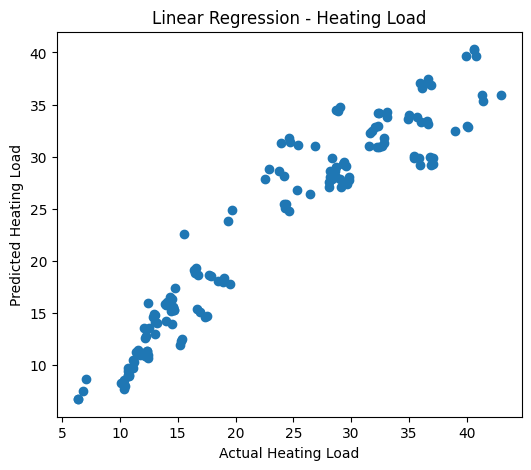


Linear Regression - Cooling_Load
RMSE: 3.14538195581142
MAE: 2.19529521051587
R2 Score: 0.8932255268607289



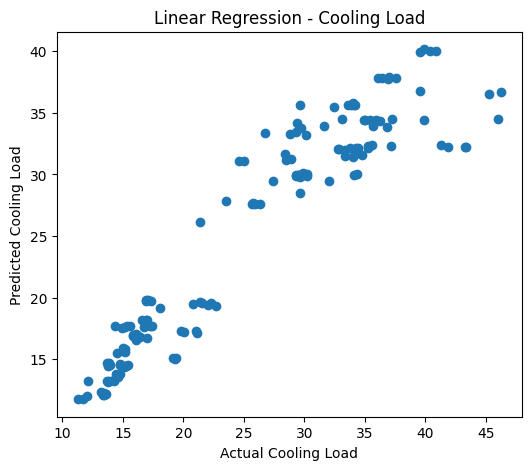

In [46]:
# 9. Linear Regression Baseline
linear_heat = LinearRegression()
linear_heat.fit(X_train, y_heat_train)
evaluate_model("Linear Regression", "Heating_Load", linear_heat, X_test, y_heat_test)
plot_predicted_vs_actual(
    y_heat_test,
    predictions[("Linear Regression", "Heating_Load")],
    "Linear Regression - Heating Load",
    "Actual Heating Load",
    "Predicted Heating Load"
)

linear_cool = LinearRegression()
linear_cool.fit(X_train, y_cool_train)
evaluate_model("\nLinear Regression", "Cooling_Load", linear_cool, X_test, y_cool_test)
plot_predicted_vs_actual(
    y_cool_test,
    predictions[("Linear Regression", "Cooling_Load")],
    "Linear Regression - Cooling Load",
    "Actual Cooling Load",
    "Predicted Cooling Load"
)


Best parameters for SVR Linear - Heating_Load:
{'C': 10, 'epsilon': 0.1}
SVR Linear - Heating_Load
RMSE: 3.091345276298288
MAE: 2.125481160371364
R2 Score: 0.9083155182887125



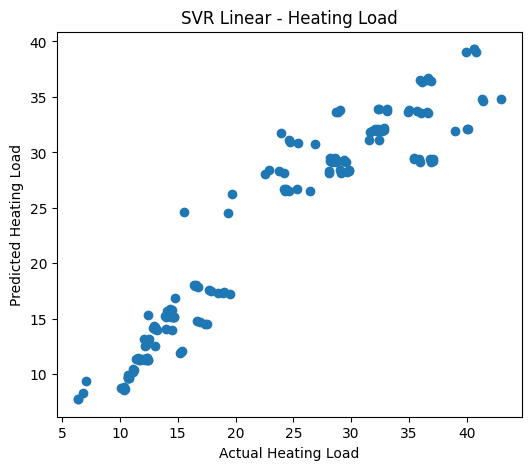


Best parameters for SVR Linear - Cooling_Load:
{'C': 10, 'epsilon': 0.2}
SVR Linear - Cooling_Load
RMSE: 3.3313721551753432
MAE: 2.1740411761707836
R2 Score: 0.880224785319159



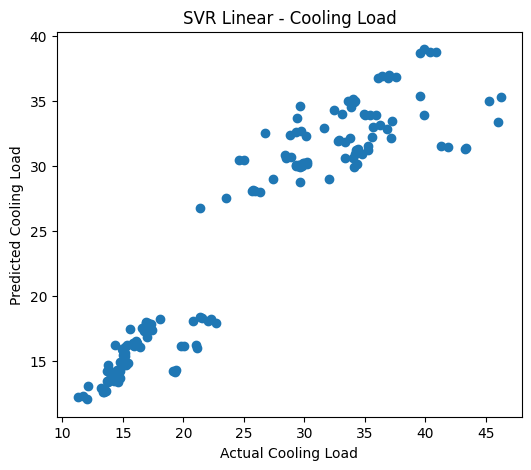

In [47]:
# 10. SVR with Linear Kernel
svr_linear_params = {
    "C": [1, 10],
    "epsilon": [0.1, 0.2]
}

svr_linear_heat = GridSearchCV(SVR(kernel="linear"), svr_linear_params, cv=3, scoring="r2")
svr_linear_heat.fit(X_train, y_heat_train)
print("Best parameters for SVR Linear - Heating_Load:")
print(svr_linear_heat.best_params_)
evaluate_model("SVR Linear", "Heating_Load", svr_linear_heat.best_estimator_, X_test, y_heat_test)
plot_predicted_vs_actual(
    y_heat_test,
    predictions[("SVR Linear", "Heating_Load")],
    "SVR Linear - Heating Load",
    "Actual Heating Load",
    "Predicted Heating Load"
)

svr_linear_cool = GridSearchCV(SVR(kernel="linear"), svr_linear_params, cv=3, scoring="r2")
svr_linear_cool.fit(X_train, y_cool_train)
print("\nBest parameters for SVR Linear - Cooling_Load:")
print(svr_linear_cool.best_params_)
evaluate_model("SVR Linear", "Cooling_Load", svr_linear_cool.best_estimator_, X_test, y_cool_test)
plot_predicted_vs_actual(
    y_cool_test,
    predictions[("SVR Linear", "Cooling_Load")],
    "SVR Linear - Cooling Load",
    "Actual Cooling Load",
    "Predicted Cooling Load"
)


Best parameters for SVR RBF - Heating_Load:
{'C': 100, 'epsilon': 0.1, 'gamma': 'scale'}
SVR RBF - Heating_Load
RMSE: 0.7419620151398584
MAE: 0.5666137068914657
R2 Score: 0.994718416513982



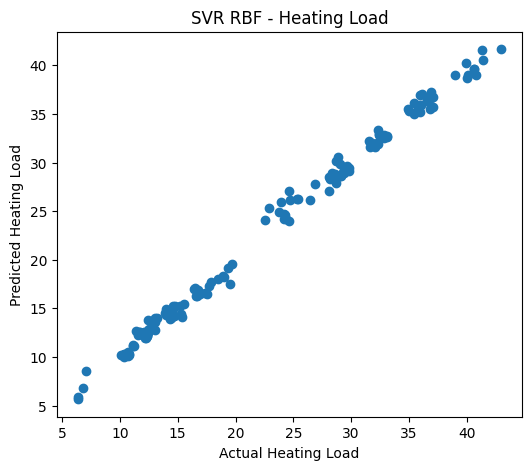


Best parameters for SVR RBF - Cooling_Load:
{'C': 100, 'epsilon': 0.1, 'gamma': 'scale'}
SVR RBF - Cooling_Load
RMSE: 1.7974940360826541
MAE: 1.143823994174146
R2 Score: 0.9651297090292034



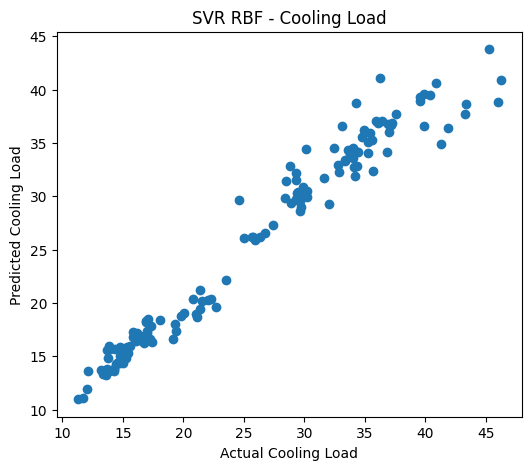

In [48]:
# 11. SVR with RBF Kernel
svr_rbf_params = {
    "C": [10, 100],
    "gamma": ["scale", 0.1],
    "epsilon": [0.1]
}

svr_rbf_heat = GridSearchCV(SVR(kernel="rbf"), svr_rbf_params, cv=3, scoring="r2")
svr_rbf_heat.fit(X_train, y_heat_train)
print("Best parameters for SVR RBF - Heating_Load:")
print(svr_rbf_heat.best_params_)
evaluate_model("SVR RBF", "Heating_Load", svr_rbf_heat.best_estimator_, X_test, y_heat_test)
plot_predicted_vs_actual(
    y_heat_test,
    predictions[("SVR RBF", "Heating_Load")],
    "SVR RBF - Heating Load",
    "Actual Heating Load",
    "Predicted Heating Load"
)

svr_rbf_cool = GridSearchCV(SVR(kernel="rbf"), svr_rbf_params, cv=3, scoring="r2")
svr_rbf_cool.fit(X_train, y_cool_train)
print("\nBest parameters for SVR RBF - Cooling_Load:")
print(svr_rbf_cool.best_params_)
evaluate_model("SVR RBF", "Cooling_Load", svr_rbf_cool.best_estimator_, X_test, y_cool_test)
plot_predicted_vs_actual(
    y_cool_test,
    predictions[("SVR RBF", "Cooling_Load")],
    "SVR RBF - Cooling Load",
    "Actual Cooling Load",
    "Predicted Cooling Load"
)


Best parameters for Neural Network - Heating_Load:
{'hidden_layer_sizes': (50,)}
Neural Network - Heating_Load
RMSE: 2.6322354420577914
MAE: 1.8035876048475683
R2 Score: 0.9335262361666689



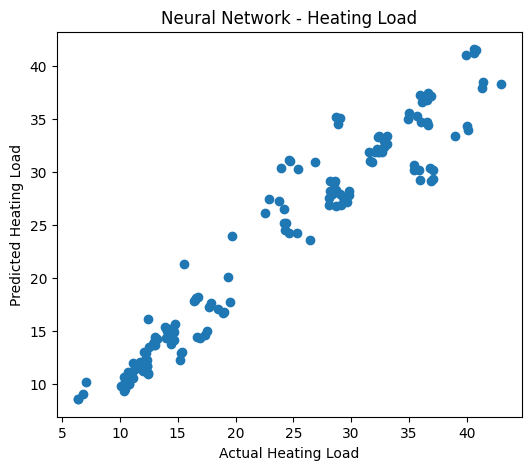


Best parameters for Neural Network - Cooling_Load:
{'hidden_layer_sizes': (50,)}
Neural Network - Cooling_Load
RMSE: 2.7263602976490566
MAE: 1.8547025855884651
R2 Score: 0.91977916971482



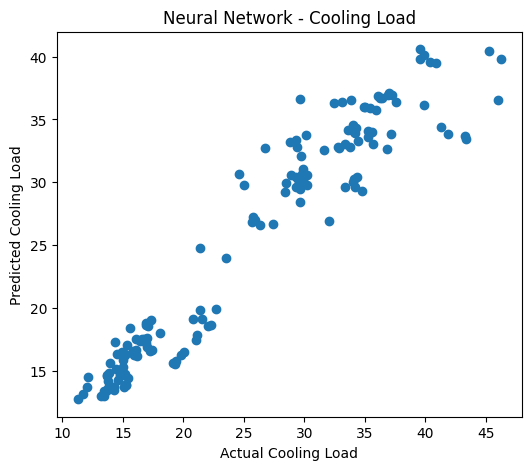

In [49]:
# 12. Neural Network
nn_params = {
    "hidden_layer_sizes": [(30,), (50,)]
}

nn_heat = GridSearchCV(
    MLPRegressor(max_iter=2000, random_state=42, early_stopping=True),
    nn_params,
    cv=3,
    scoring="r2"
)
nn_heat.fit(X_train, y_heat_train)
print("Best parameters for Neural Network - Heating_Load:")
print(nn_heat.best_params_)
evaluate_model("Neural Network", "Heating_Load", nn_heat.best_estimator_, X_test, y_heat_test)
plot_predicted_vs_actual(
    y_heat_test,
    predictions[("Neural Network", "Heating_Load")],
    "Neural Network - Heating Load",
    "Actual Heating Load",
    "Predicted Heating Load"
)

nn_cool = GridSearchCV(
    MLPRegressor(max_iter=2000, random_state=42, early_stopping=True),
    nn_params,
    cv=3,
    scoring="r2"
)
nn_cool.fit(X_train, y_cool_train)
print("\nBest parameters for Neural Network - Cooling_Load:")
print(nn_cool.best_params_)
evaluate_model("Neural Network", "Cooling_Load", nn_cool.best_estimator_, X_test, y_cool_test)
plot_predicted_vs_actual(
    y_cool_test,
    predictions[("Neural Network", "Cooling_Load")],
    "Neural Network - Cooling Load",
    "Actual Cooling Load",
    "Predicted Cooling Load"
)


In [50]:
# 13. Model Comparison Table
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by=["Target", "R2 Score"], ascending=[True, False])
results_df


,Model,Target,RMSE,MAE,R2 Score
5,SVR RBF,Cooling_Load,1.797494,1.143824,0.965130
17,SVR RBF,Cooling_Load,1.797494,1.143824,0.965130
7,Neural Network,Cooling_Load,2.726360,1.854703,0.919779
9,Neural Network,Cooling_Load,2.726360,1.854703,0.919779
19,Neural Network,Cooling_Load,2.726360,1.854703,0.919779
1,Linear Regression,Cooling_Load,3.145382,2.195295,0.893226
11,Linear Regression,Cooling_Load,3.145382,2.195295,0.893226
13,\nLinear Regression,Cooling_Load,3.145382,2.195295,0.893226
3,SVR Linear,Cooling_Load,3.331372,2.174041,0.880225
15,SVR Linear,Cooling_Load,3.331372,2.174041,0.880225


In [51]:
# 14. Find Best Model for Each Target
best_heating = results_df[results_df["Target"] == "Heating_Load"].iloc[0]
best_cooling = results_df[results_df["Target"] == "Cooling_Load"].iloc[0]

print("Best model for Heating_Load:")
print(best_heating)

print("\nBest model for Cooling_Load:")
print(best_cooling)


Best model for Heating_Load:
Model            SVR RBF
Target      Heating_Load
RMSE            0.741962
MAE             0.566614
R2 Score        0.994718
Name: 4, dtype: object

Best model for Cooling_Load:
Model            SVR RBF
Target      Cooling_Load
RMSE            1.797494
MAE             1.143824
R2 Score         0.96513
Name: 5, dtype: object


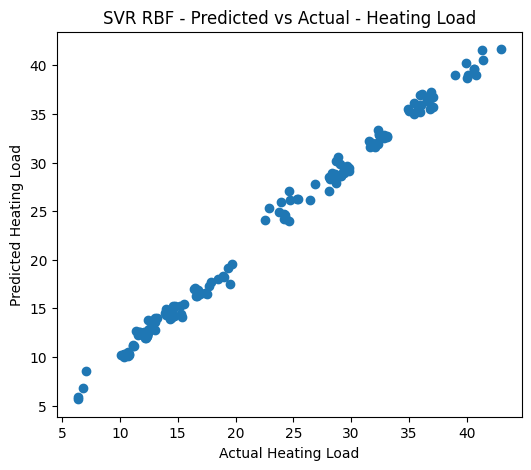

In [52]:
# 15. Predicted vs Actual Plot for Best Heating Load Model
best_heating_model_name = best_heating["Model"]
y_heat_pred = predictions[(best_heating_model_name, "Heating_Load")]

plt.figure(figsize=(6, 5))
plt.scatter(y_heat_test, y_heat_pred)
plt.xlabel("Actual Heating Load")
plt.ylabel("Predicted Heating Load")
plt.title("SVR RBF - Predicted vs Actual - Heating Load")
plt.show()


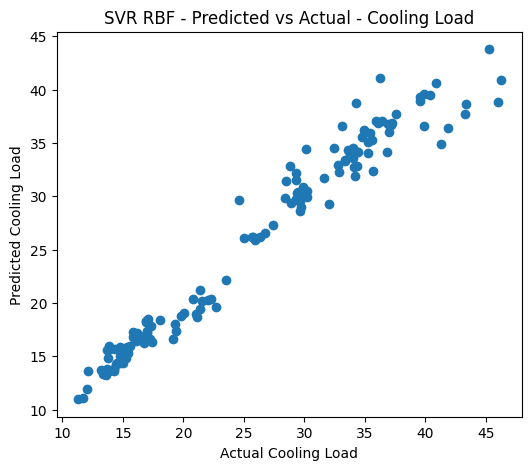

In [53]:
# 16. Predicted vs Actual Plot for Best Cooling Load Model
best_cooling_model_name = best_cooling["Model"]
y_cool_pred = predictions[(best_cooling_model_name, "Cooling_Load")]

plt.figure(figsize=(6, 5))
plt.scatter(y_cool_test, y_cool_pred)
plt.xlabel("Actual Cooling Load")
plt.ylabel("Predicted Cooling Load")
plt.title("SVR RBF - Predicted vs Actual - Cooling Load")
plt.show()


In [54]:
# 17. Final Conclusion
print("Final Conclusion")
print("----------------")
print("This project used building characteristics to predict Heating Load and Cooling Load.")
print("The dataset was checked for missing values, and feature scaling was applied using StandardScaler.")
print("Linear Regression was used as the baseline model.")
print("SVR with linear and RBF kernels and a Neural Network were trained and tuned using GridSearchCV.")
print("For Heating Load, the best model was:", best_heating["Model"])
print("For Cooling Load, the best model was:", best_cooling["Model"])
print("The best models were chosen because they achieved the highest R2 Score and lower RMSE and MAE values.")
print("This means their predictions were closer to the actual energy load values compared to the other models.")

Final Conclusion
----------------
This project used building characteristics to predict Heating Load and Cooling Load.
The dataset was checked for missing values, and feature scaling was applied using StandardScaler.
Linear Regression was used as the baseline model.
SVR with linear and RBF kernels and a Neural Network were trained and tuned using GridSearchCV.
For Heating Load, the best model was: SVR RBF
For Cooling Load, the best model was: SVR RBF
The best models were chosen because they achieved the highest R2 Score and lower RMSE and MAE values.
This means their predictions were closer to the actual energy load values compared to the other models.
